In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [28]:
df = pd.read_csv('../datasets/properties_missing_value_imputation.csv')

In [29]:
df.shape

(3554, 18)

In [30]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


## 1. Geo Map

In [ ]:
latlong = pd.read_csv('../artifacts/latlong.csv')

In [32]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [33]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [34]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [35]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [36]:
new_df = df.merge(latlong, on='sector')

In [37]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='object')

In [38]:
new_df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,...,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,coordinates,latitude,longitude
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,...,0.0,0.0,0.0,0.0,0.0,0.0,8.0,"28.4160° N, 76.9914° E",28.4160,76.9914
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,...,1.0,1.0,0.0,0.0,0.0,0.0,38.0,"28.4253° N, 76.9439° E",28.4253,76.9439
2,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,...,0.0,1.0,0.0,0.0,1.0,1.0,174.0,"28.4079° N, 76.9153° E",28.4079,76.9153
3,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,...,0.0,0.0,1.0,0.0,0.0,0.0,159.0,"28.4750° N, 76.9715° E",28.4750,76.9715
4,flat,paras quartier,gwal pahari,7.50,14019.0,4.0,4.0,3+,20.0,New Property,...,0.0,1.0,0.0,1.0,1.0,1.0,49.0,"28.4484° N, 77.0210° E",28.4484,77.0210


In [39]:
new_df.groupby('sector').mean(numeric_only=True)

,price,price_per_sqft,bedRoom,bathroom,floorNum,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
sector,,,,,,,,,,,,,,,
gwal pahari,3.192222,9585.777778,3.277778,3.444444,8.333333,3056.166667,0.222222,0.388889,0.055556,0.277778,0.166667,0.444444,75.388889,28.4484,77.0210
manesar,0.962258,4608.064516,3.096774,3.064516,5.129032,2027.367742,0.032258,0.580645,0.000000,0.032258,0.032258,0.096774,31.451613,28.3515,76.9428
sector 1,1.860000,8249.833333,3.833333,3.833333,5.166667,2327.833333,0.000000,0.333333,0.000000,0.000000,0.000000,0.333333,1.666667,28.3663,76.9456
sector 10,2.092857,11866.571429,3.142857,2.857143,4.571429,1908.857143,0.000000,0.000000,0.000000,0.142857,0.285714,0.142857,22.285714,28.4537,77.0009
sector 102,1.696636,10603.822430,2.785047,3.046729,8.897196,1556.130841,0.158879,0.495327,0.074766,0.093458,0.037383,0.308411,94.644860,28.4750,76.9715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sector 91,1.648235,7586.117647,3.235294,3.176471,7.235294,2028.647059,0.294118,0.470588,0.176471,0.411765,0.058824,0.529412,75.352941,28.4014,76.9225
sector 92,0.934000,5928.290000,3.200000,3.020000,7.500000,1571.341800,0.080000,0.220000,0.010000,0.050000,0.120000,0.200000,52.370000,28.4079,76.9153
sector 93,0.848889,8009.888889,2.555556,2.666667,8.555556,1017.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.222222,34.555556,28.4153,76.9326


In [40]:
group_df = new_df.groupby('sector')[['price','price_per_sqft','built_up_area','latitude','longitude']].mean(numeric_only=True)

In [41]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 10,2.092857,11866.571429,1908.857143,28.4537,77.0009
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
...,...,...,...,...,...
sector 91,1.648235,7586.117647,2028.647059,28.4014,76.9225
sector 92,0.934000,5928.290000,1571.341800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326


In [42]:
# Apply Filters
import plotly.express as px

fig = px.scatter_map(
    group_df,
    lat="latitude",
    lon="longitude",
    color="price_per_sqft",
    size='built_up_area',
    color_continuous_scale=px.colors.cyclical.IceFire,
    zoom=10,
    text=group_df.index
)
fig.show(renderer="browser")  # works outside Jupyter

In [ ]:
# new_df.to_csv('../artifacts/data_viz1.csv',index=False)

NameError: name 'asd' is not defined

## 2. Word Cloud of Amenities 

Todo: Add Drop down for sector

In [45]:
df1 = pd.read_csv('../datasets/properties.csv')

In [50]:
df1.head(2)

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 BHK Flat in Sector 36 Sohna,flat,signature global park 4,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,not available,"144, Sector 36 Sohna, Gurgaon, Haryana",2.0,NaN,0 to 1 Year Old,"['Sector 55-56 Metro Station', 'The Leaf Mall ...",We need to shift somewhere else,NaN,"['Lift(s)', 'Park']",NaN
1,2 BHK Flat in Sector 89 Gurgaon,flat,smart world gems,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,"study room,servant room","O 118d, Sector 89 Gurgaon, Gurgaon, Haryana",4.0,NaN,Within 6 months,"['Sant Soordas Sihi Metro Station', 'Airia Mal...",Smartworld gem4 th floor new construction,NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s...","['Environment4 out of 5', 'Lifestyle4 out of 5..."


In [51]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0


In [47]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [48]:
wordcloud_df.head()

,features,sector
0,"['Lift(s)', 'Park']",sector 36
1,"['Power Back-up', 'Intercom Facility', 'Lift(s...",sector 89
2,"['Intercom Facility', 'Lift(s)', 'Park']",sohna road
3,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 92
4,"['Centrally Air Conditioned', 'Water purifier'...",sector 102


In [ ]:
# Do it with sector for drop down
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [53]:
main

['Lift(s)',
 'Park',
 'Power Back-up',
 'Intercom Facility',
 'Lift(s)',
 'Swimming Pool',
 'Park',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Intercom Facility',
 'Lift(s)',
 'Park',
 'Feng Shui / Vaastu Compliant',
 'Security / Fire Alarm',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Park',
 'Visitor Parking',
 'Centrally Air Conditioned',
 'Water purifier',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Bank Attached Property',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Recently Renovated',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',

In [54]:
from wordcloud import WordCloud

In [55]:
feature_text = ' '.join(main)

In [57]:
feature_text

'Lift(s) Park Power Back-up Intercom Facility Lift(s) Swimming Pool Park Piped-gas Internet/wi-fi connectivity Fitness Centre / GYM Club house / Community Center Intercom Facility Lift(s) Park Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Park Visitor Parking Centrally Air Conditioned Water purifier Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Centrally Air Conditioned Water purifier Security / Fire Alarm Feng Shui / Vaas

In [65]:
import pickle
pickle.dump(feature_text, open('../artifacts/feature_text.pkl','wb'))

In [58]:
feature_text

'Lift(s) Park Power Back-up Intercom Facility Lift(s) Swimming Pool Park Piped-gas Internet/wi-fi connectivity Fitness Centre / GYM Club house / Community Center Intercom Facility Lift(s) Park Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Park Visitor Parking Centrally Air Conditioned Water purifier Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Centrally Air Conditioned Water purifier Security / Fire Alarm Feng Shui / Vaas

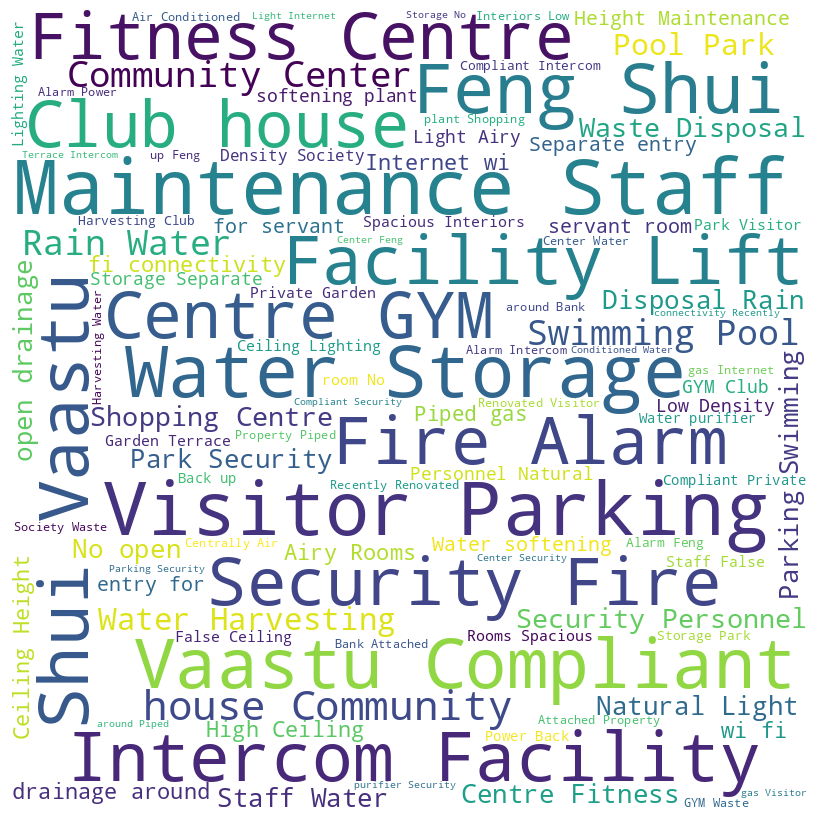

In [59]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [66]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [67]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [68]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [69]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()


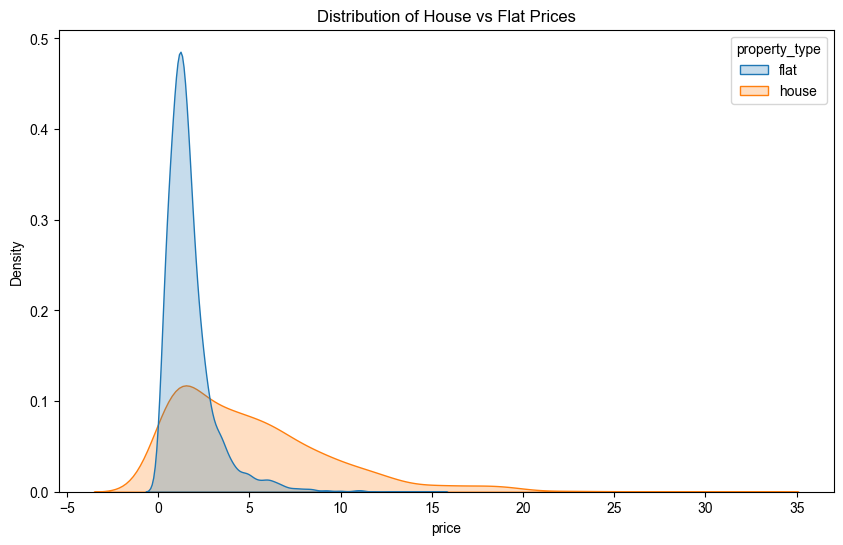

In [ ]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='price',
    hue='property_type',
    fill=True,
    common_norm=False
)
plt.title("Distribution of House vs Flat Prices")
plt.show()

# plt.figure(figsize=(10,6))
# sns.histplot(data=df, x='price', hue='property_type',   # house vs flat kde=True, bins=30, stat="density",        # better for comparison common_norm=False      # keeps distributions independent
# )
# plt.title("Distribution of House vs Flat Prices")
# plt.show()

In [74]:
new_df['sector'].unique()

array(['sector 36', 'sector 89', 'sector 92', 'sector 102', 'gwal pahari',
       'sector 108', 'sector 105', 'sector 26', 'sector 109', 'sector 28',
       'sector 65', 'sector 12', 'sector 85', 'sector 30', 'sector 107',
       'sector 3', 'sector 2', 'sector 41', 'sector 4', 'sector 62',
       'sector 49', 'sector 81', 'sector 66', 'sector 86', 'sector 48',
       'sector 51', 'sector 37', 'sector 111', 'sector 67', 'sector 113',
       'sector 13', 'sector 61', 'sector 69', 'sector 67a', 'sector 37d',
       'sector 82', 'sector 53', 'sector 74', 'sector 52', 'sector 43',
       'sector 14', 'sector 25', 'sector 95', 'sector 56', 'sector 83',
       'sector 104', 'sector 88a', 'sector 55', 'sector 50', 'sector 84',
       'sector 91', 'sector 76', 'sector 82a', 'sector 78', 'manesar',
       'sector 93', 'sector 7', 'sector 71', 'sector 110', 'sector 33',
       'sector 70', 'sector 103', 'sector 90', 'sector 38', 'sector 79',
       'sector 112', 'sector 22', 'sector 59', 'sector

In [78]:
new_df['sector'].unique().tolist().insert(0,'overall')